# Machine-learning prediction of in-hospital mortality after PCI for unprotected left main disease
## Gulf-LM registry — final reproducible analysis (natural class distribution)

This notebook reproduces the **final** analysis reported in the manuscript. Key methodological points:

* All models are trained on the **natural class distribution** (no oversampling, no class weighting),
  so predicted probabilities remain calibrated.
* Point estimates come from **pooled out-of-fold predictions**; 95% confidence intervals are obtained by
  **bootstrap resampling** (cross-validation-variance intervals are anticonservative).
* Discrimination is assessed with **AUROC** and **AUPRC**, calibration with the **Brier score, calibration
  slope, and calibration-in-the-large**.
* Interpretability uses **SHAP**, corroborated by **permutation importance**.

**Requirements:** `pip install pandas numpy scikit-learn xgboost lightgbm catboost shap statsmodels matplotlib openpyxl xlrd`.
Place `PCIdata.xls` (complete-case cohort) and `sheet.dta` (full cohort with continuous covariates) beside this notebook.



In [1]:
import warnings, os, re, json
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier,
                              HistGradientBoostingClassifier, GradientBoostingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             roc_curve, precision_recall_curve, confusion_matrix)
from sklearn.inspection import permutation_importance
from scipy.optimize import minimize_scalar
RNG = 42
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110, 'font.family': 'DejaVu Sans'})
CACHE = 'analysis_v2/oof_nat'; os.makedirs(CACHE, exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Data, leakage control, and events-per-variable

In [2]:
df = pd.read_excel('PCIdata.xls')
BINARY = ['Sex','Age_Cat70','Smoking','DM','Hx_MI','Hx_PCI','Hx_CABG','CKD','PAD','Hx_CVA','AF','Hx_CHF',
          'ACS_STEMI','EF_Cat40','PulmonaryHTN','VHD','CrCl_Cat60','ProximalLM','Brady','Tachy','Arrest','shock']
CONT = ['EuroScore','Angio_SYNTAX']; FEATURES = BINARY + CONT
LEAK = ['Hospital_HF','Hospital_MI','Hospital_LesionRevasc','Hospital_VesselRevasc','Hospital_CVA',
        'Hospital_MACE','LOS','Angio_SYNTAX_Cat','Angio_SYNTAX_High']
assert not (set(FEATURES) & set(LEAK)), 'leakage column in feature set!'
LABELS = {'Sex':'Male sex','Age_Cat70':'Age >70y','Smoking':'Smoking','DM':'Diabetes','Hx_MI':'Prior MI',
 'Hx_PCI':'Prior PCI','Hx_CABG':'Prior CABG','CKD':'CKD','PAD':'PAD','Hx_CVA':'Prior CVA','AF':'Atrial fibrillation',
 'Hx_CHF':'Chronic heart failure','ACS_STEMI':'STEMI','EF_Cat40':'EF <40%','PulmonaryHTN':'Pulmonary HTN',
 'VHD':'Valvular disease','CrCl_Cat60':'CrCl <60','ProximalLM':'Proximal LM','Brady':'Bradyarrhythmia',
 'Tachy':'Tachyarrhythmia','Arrest':'Cardiac arrest','shock':'Cardiogenic shock','EuroScore':'EuroSCORE II','Angio_SYNTAX':'SYNTAX score'}
X = df[FEATURES].copy(); y = df['death'].astype(int).values
print(f'n = {len(y)}   events = {y.sum()}   rate = {y.mean():.3%}   predictors = {len(FEATURES)}')
print(f'events-per-variable (EPV) = {y.sum()/len(FEATURES):.2f}   missing predictor cells = {int(X.isnull().sum().sum())}')

n = 1205   events = 45   rate = 3.734%   predictors = 24
events-per-variable (EPV) = 1.88   missing predictor cells = 0


## 2. Missing-data reconciliation (full cohort) and multiple-imputation sensitivity
The analysed complete-case cohort (n=1,205) is drawn from 1,222 PCI patients; 17 (1.4%) were excluded for
missing data (mostly the EuroSCORE II). Multiple imputation of the full cohort gives essentially identical
discrimination.

In [3]:
try:
    full = pd.read_stata('sheet.dta')
    n_full = len(full); n_excl = n_full - len(y)
    print(f'Full PCI cohort = {n_full};  excluded for missing data ≈ {n_excl} ({n_excl/n_full:.1%})')
    mi = np.load(f'{CACHE}/_mi.npy'); mi_y = np.load(f'{CACHE}/_mi_y.npy')
    print(f'Multiple-imputation full-cohort random forest AUROC = {roc_auc_score(mi_y, mi):.3f} '
          f'(complete-case AUROC ≈ 0.904 — materially unchanged)')
except FileNotFoundError:
    print('sheet.dta / cached MI not found — skipping the imputation sensitivity analysis.')

Full PCI cohort = 1222;  excluded for missing data ≈ 17 (1.4%)
Multiple-imputation full-cohort random forest AUROC = 0.903 (complete-case AUROC ≈ 0.904 — materially unchanged)


## 3. Correlation heatmap (collinearity screening) — Supplementary Figure 1

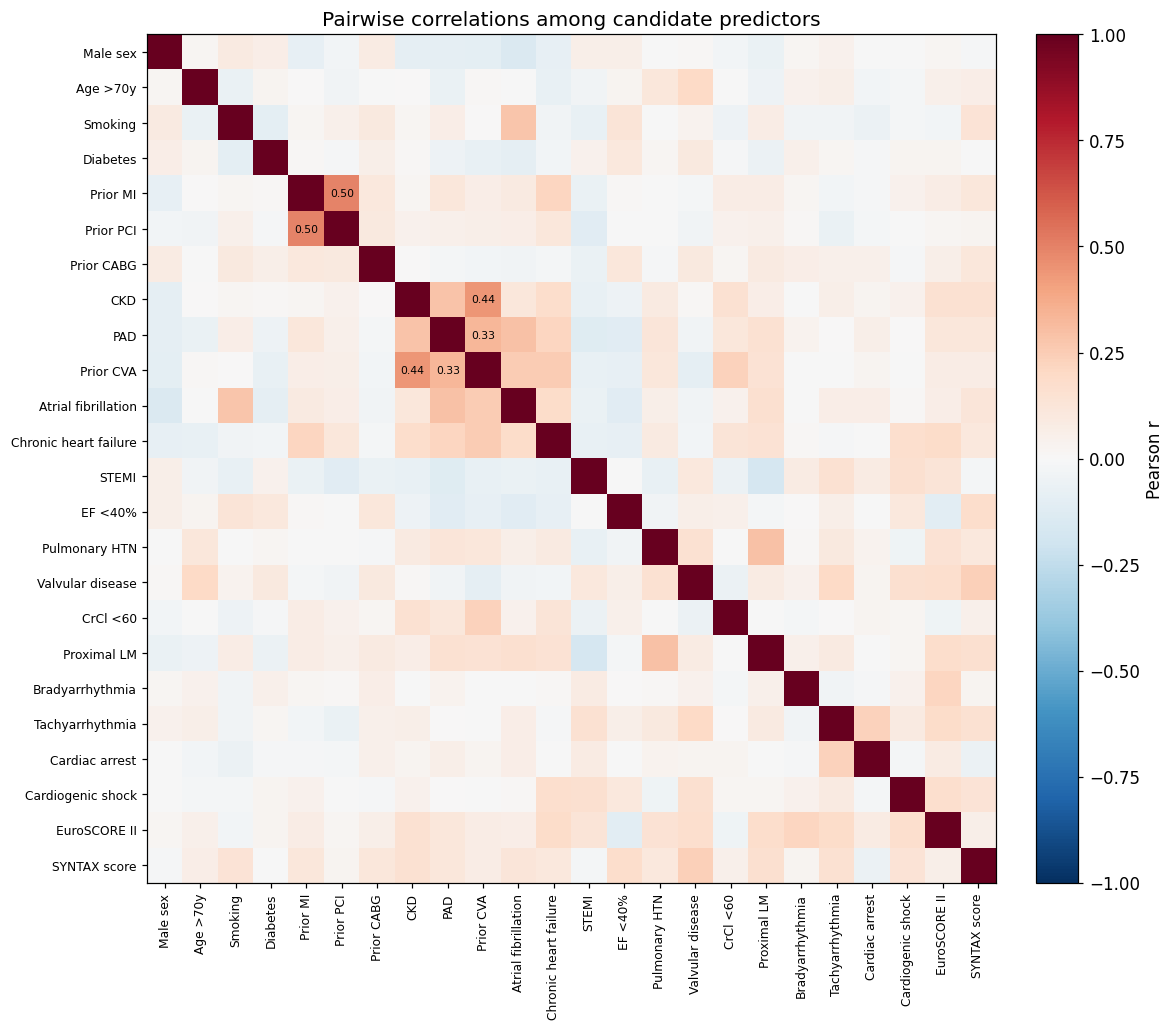

Max off-diagonal |r| = 0.5 → no strong collinearity; all 24 predictors retained.


In [4]:
corr = X.rename(columns=LABELS).corr(method='pearson'); names = [LABELS[f] for f in FEATURES]
fig, ax = plt.subplots(figsize=(11, 9.5))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=90, fontsize=8)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
for i in range(len(names)):
    for j in range(len(names)):
        v = corr.values[i, j]
        if i != j and abs(v) >= 0.30:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7, color='white' if abs(v)>0.6 else 'black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('Pearson r')
ax.set_title('Pairwise correlations among candidate predictors'); plt.tight_layout(); plt.show()
print('Max off-diagonal |r| =', round(np.abs(corr.values[~np.eye(len(names), dtype=bool)]).max(), 2),
      '→ no strong collinearity; all 24 predictors retained.')

## 4. Model library (natural class distribution — no class weighting, no SMOTE)

In [5]:
def ct(): return ColumnTransformer([('c', StandardScaler(), CONT)], remainder='passthrough')
def sc(clf): return Pipeline([('s', ct()), ('m', clf)])
MODELS = {
 'Random Forest': RandomForestClassifier(n_estimators=600, min_samples_leaf=2, random_state=RNG, n_jobs=-1),
 'Extra Trees': ExtraTreesClassifier(n_estimators=600, min_samples_leaf=2, random_state=RNG, n_jobs=-1),
 'Logistic Regression (L2)': sc(LogisticRegression(max_iter=5000, C=1.0, random_state=RNG)),
 'Logistic Elastic-Net': sc(LogisticRegression(max_iter=5000, penalty='elasticnet', solver='saga', l1_ratio=0.5, C=0.5, random_state=RNG)),
 'Decision Tree': DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=RNG),
 'K-Nearest Neighbors': sc(KNeighborsClassifier(n_neighbors=15)),
 'Support Vector Machine': sc(SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RNG)),
 'Naive Bayes': sc(GaussianNB()),
 'AdaBoost': AdaBoostClassifier(n_estimators=300, learning_rate=0.5, random_state=RNG),
 'Gradient Boosting': GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=RNG),
 'HistGradientBoosting': HistGradientBoostingClassifier(max_iter=400, learning_rate=0.05, max_depth=3, l2_regularization=1.0, random_state=RNG),
}
try:
    from xgboost import XGBClassifier; from lightgbm import LGBMClassifier; from catboost import CatBoostClassifier
    MODELS['XGBoost'] = XGBClassifier(n_estimators=400, learning_rate=0.03, max_depth=3, subsample=0.8, colsample_bytree=0.8,
                                      min_child_weight=3, reg_lambda=2.0, eval_metric='logloss', random_state=RNG, n_jobs=-1)
    MODELS['LightGBM'] = LGBMClassifier(n_estimators=400, learning_rate=0.03, max_depth=3, num_leaves=7, subsample=0.8,
                                        colsample_bytree=0.8, min_child_samples=15, reg_lambda=2.0, random_state=RNG, n_jobs=1, verbose=-1)
    MODELS['CatBoost'] = CatBoostClassifier(iterations=400, learning_rate=0.03, depth=3, l2_leaf_reg=5.0, random_seed=RNG, verbose=0)
except ImportError:
    print('xgboost/lightgbm/catboost not installed — boosted-tree models skipped.')
BASE = {'EuroSCORE II': ['EuroScore'], 'SYNTAX score': ['Angio_SYNTAX'], 'EuroSCORE II + SYNTAX': ['EuroScore','Angio_SYNTAX']}
for b in BASE: MODELS[b] = Pipeline([('s', StandardScaler()), ('m', LogisticRegression(max_iter=5000, random_state=RNG))])
print(f'{len(MODELS)} models defined (14 ML algorithms + 3 traditional-score baselines).')

17 models defined (14 ML algorithms + 3 traditional-score baselines).


## 5. Out-of-fold predictions (compute or load cache)
5-fold stratified cross-validation, 5 repeats, out-of-fold probabilities averaged over repeats.

In [6]:
from sklearn.base import clone
def compute_oof(est, Xin, n_rep=5):
    P = np.zeros((len(y), n_rep))
    for r in range(n_rep):
        for tr, te in StratifiedKFold(5, shuffle=True, random_state=RNG+r).split(Xin, y):
            m = clone(est); m.fit(Xin.iloc[tr], y[tr]); P[te, r] = m.predict_proba(Xin.iloc[te])[:, 1]
    return P.mean(1)
def oof_path(name): return f'{CACHE}/' + re.sub(r'[^A-Za-z0-9]+', '_', name) + '.npy'
OOF = {}
for name, est in MODELS.items():
    p = oof_path(name)
    if os.path.exists(p):
        OOF[name] = np.load(p)
    else:
        Xin = X[BASE[name]] if name in BASE else X
        OOF[name] = compute_oof(est, Xin); np.save(p, OOF[name])
print('Out-of-fold predictions ready for', len(OOF), 'models.')

Out-of-fold predictions ready for 17 models.


## 6. Table 2 — discrimination and calibration with bootstrap 95% CIs

In [7]:
rng = np.random.default_rng(7)
def boot_ci(yy, p, fn, nb=400):
    idx = np.arange(len(yy)); b = []
    for _ in range(nb):
        s = rng.choice(idx, len(yy), replace=True)
        if yy[s].sum() < 2: continue
        b.append(fn(yy[s], p[s]))
    return np.percentile(b, 2.5), np.percentile(b, 97.5)
rows = []
for name, p in OOF.items():
    lo, hi = boot_ci(y, p, roc_auc_score)
    rows.append({'Model': name, 'AUROC': roc_auc_score(y, p), 'lo': lo, 'hi': hi,
                 'AUPRC': average_precision_score(y, p), 'Brier': brier_score_loss(y, p)})
tab = pd.DataFrame(rows).sort_values('AUROC', ascending=False).reset_index(drop=True)
tab['AUROC (95% CI)'] = tab.apply(lambda r: f"{r.AUROC:.3f} ({r.lo:.3f}-{r.hi:.3f})", axis=1)
Table2 = tab[['Model','AUROC (95% CI)','AUPRC','Brier']].round(3)
Table2

,Model,AUROC (95% CI),AUPRC,Brier
0,Random Forest,0.904 (0.852-0.937),0.353,0.029
1,Extra Trees,0.895 (0.847-0.935),0.291,0.030
2,Logistic Elastic-Net,0.879 (0.825-0.925),0.293,0.031
3,CatBoost,0.874 (0.817-0.927),0.319,0.030
4,AdaBoost,0.870 (0.807-0.920),0.298,0.130
5,Support Vector Machine,0.869 (0.794-0.927),0.327,0.032
6,Logistic Regression (L2),0.868 (0.827-0.910),0.295,0.031
7,Gradient Boosting,0.866 (0.799-0.923),0.328,0.030
8,Naive Bayes,0.865 (0.803-0.916),0.216,0.283
9,XGBoost,0.864 (0.804-0.913),0.278,0.031


## 7. Model-comparison figure (AUROC with bootstrap CI) — Supplementary Figure 4

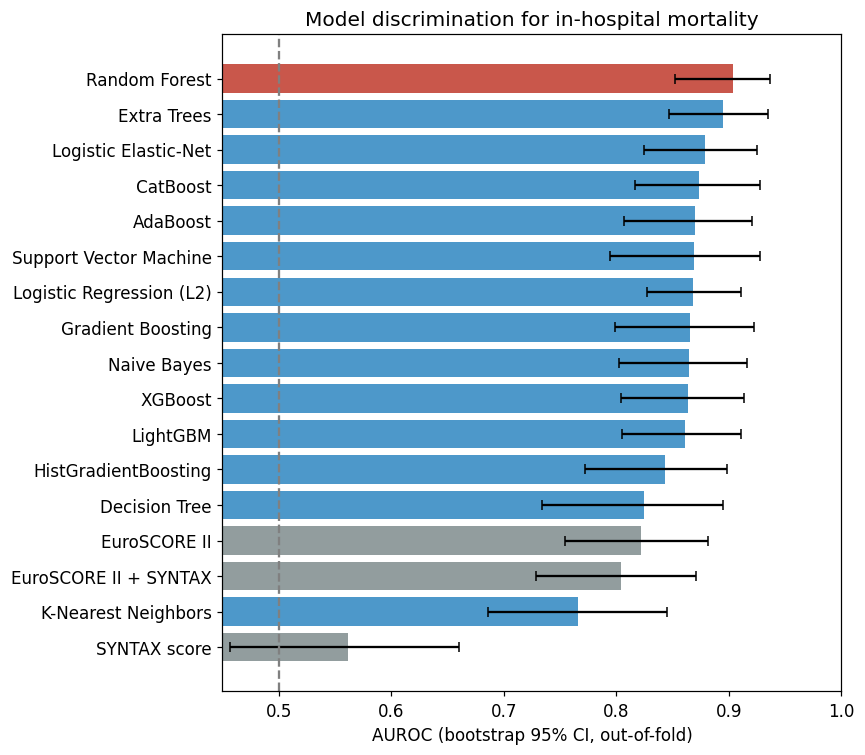

In [8]:
trad = ['EuroSCORE II','SYNTAX score','EuroSCORE II + SYNTAX']
d2 = tab.sort_values('AUROC')
col = ['#c0392b' if m=='Random Forest' else ('#7f8c8d' if m in trad else '#2e86c1') for m in d2['Model']]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(d2['Model'], d2['AUROC'], xerr=[d2['AUROC']-d2['lo'], d2['hi']-d2['AUROC']], color=col, alpha=.85, capsize=3)
ax.axvline(0.5, ls='--', c='gray'); ax.set_xlim(0.45, 1.0); ax.set_xlabel('AUROC (bootstrap 95% CI, out-of-fold)')
ax.set_title('Model discrimination for in-hospital mortality'); plt.tight_layout(); plt.show()

## 8. ROC and precision–recall curves — Figure 2

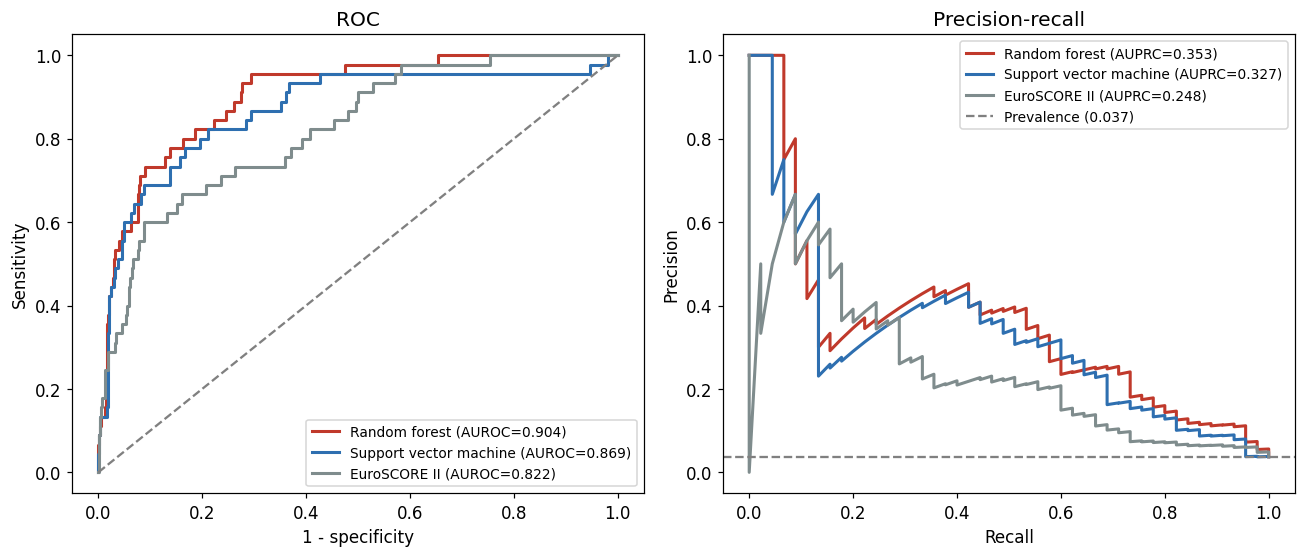

In [9]:
series = [(OOF['Random Forest'],'Random forest','#c0392b'),
          (OOF['Support Vector Machine'],'Support vector machine','#2e6fb0'),
          (OOF['EuroSCORE II'],'EuroSCORE II','#7f8c8d')]
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,5.2))
for p,l,c in series:
    f_,t_,_=roc_curve(y,p); a1.plot(f_,t_,color=c,lw=2,label=f'{l} (AUROC={roc_auc_score(y,p):.3f})')
a1.plot([0,1],[0,1],'--',c='gray'); a1.set_xlabel('1 - specificity'); a1.set_ylabel('Sensitivity'); a1.set_title('ROC'); a1.legend(loc='lower right',fontsize=9)
for p,l,c in series:
    pr,rc,_=precision_recall_curve(y,p); a2.plot(rc,pr,color=c,lw=2,label=f'{l} (AUPRC={average_precision_score(y,p):.3f})')
a2.axhline(y.mean(),ls='--',c='gray',label=f'Prevalence ({y.mean():.3f})'); a2.set_xlabel('Recall'); a2.set_ylabel('Precision'); a2.set_title('Precision-recall'); a2.legend(loc='upper right',fontsize=9)
plt.tight_layout(); plt.show()

## 9. Final model (random forest): calibration, risk bands, operating point — Supplementary Figure 5

Mean predicted 0.037 vs observed 0.037 | calibration slope 1.20 | calibration-in-the-large 0.02 | Brier 0.029

Risk bands (observed in-hospital mortality):
  Low (<2%)            n= 798  deaths= 2  observed=0.3%
  Intermediate (2-5%)  n= 168  deaths= 7  observed=4.2%
  High (>=5%)          n= 239  deaths=36  observed=15.1%

Youden operating point: sensitivity 96%, specificity 71%, PPV 11%, NPV 99.8% (caught 43/45 deaths)


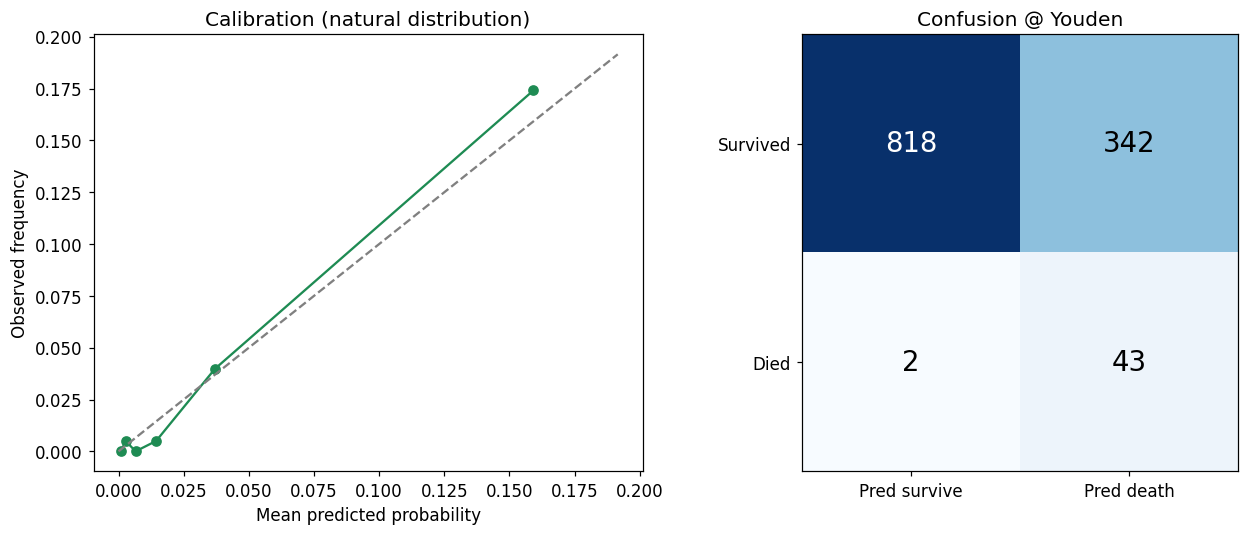

In [10]:
p_rf = OOF['Random Forest']; eps = 1e-6
lg = np.log(np.clip(p_rf,eps,1-eps)/(1-np.clip(p_rf,eps,1-eps)))
slope = LogisticRegression(C=1e6).fit(lg.reshape(-1,1), y).coef_[0][0]
citl = minimize_scalar(lambda a: -np.sum(y*np.log(1/(1+np.exp(-(a+lg))))+(1-y)*np.log(1-1/(1+np.exp(-(a+lg))))),
                       bounds=(-5,5), method='bounded').x
print(f'Mean predicted {p_rf.mean():.3f} vs observed {y.mean():.3f} | calibration slope {slope:.2f} | calibration-in-the-large {citl:.2f} | Brier {brier_score_loss(y,p_rf):.3f}')
print('\nRisk bands (observed in-hospital mortality):')
for nm, mask in [('Low (<2%)', p_rf<0.02), ('Intermediate (2-5%)', (p_rf>=0.02)&(p_rf<0.05)), ('High (>=5%)', p_rf>=0.05)]:
    n = mask.sum(); print(f'  {nm:20s} n={n:4d}  deaths={int(y[mask].sum()):2d}  observed={y[mask].sum()/n:.1%}')
fpr,tpr,thr = roc_curve(y, p_rf); yt = thr[np.argmax(tpr-fpr)]
tn,fp,fn,tp = confusion_matrix(y,(p_rf>=yt).astype(int)).ravel()
print(f'\nYouden operating point: sensitivity {tp/(tp+fn):.0%}, specificity {tn/(tn+fp):.0%}, '
      f'PPV {tp/(tp+fp):.0%}, NPV {tn/(tn+fn):.1%} (caught {tp}/{tp+fn} deaths)')
from sklearn.calibration import calibration_curve
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,5))
frac,mp=calibration_curve(y,p_rf,n_bins=6,strategy='quantile')
a1.plot(mp,frac,'o-',color='#1e8b53'); lim=max(mp.max(),frac.max())*1.1; a1.plot([0,lim],[0,lim],'--',c='gray')
a1.set_xlabel('Mean predicted probability'); a1.set_ylabel('Observed frequency'); a1.set_title('Calibration (natural distribution)')
cm=np.array([[tn,fp],[fn,tp]]); a2.imshow(cm,cmap='Blues')
for i in range(2):
    for j in range(2): a2.text(j,i,cm[i,j],ha='center',va='center',fontsize=18,color='white' if cm[i,j]>cm.max()/2 else 'black')
a2.set_xticks([0,1]); a2.set_xticklabels(['Pred survive','Pred death']); a2.set_yticks([0,1]); a2.set_yticklabels(['Survived','Died']); a2.set_title(f'Confusion @ Youden')
plt.tight_layout(); plt.show()

## 10. Explainability — SHAP and permutation importance (Figure 3)
SHAP and permutation importance agree on the ranking, arguing against a high-cardinality bias.

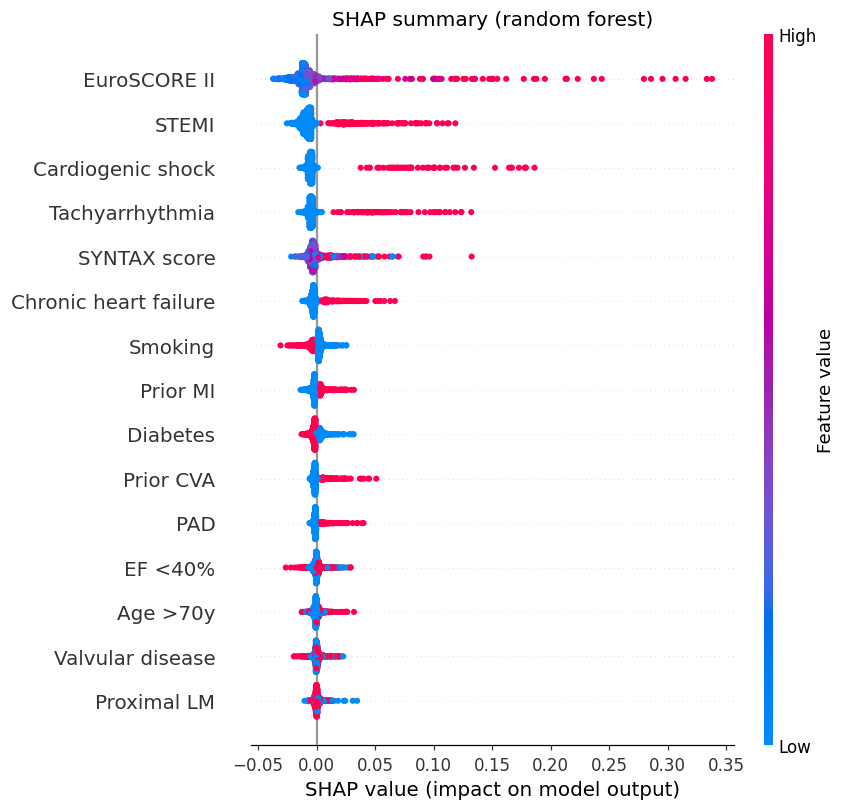

,Feature,mean_abs_SHAP,perm_importance
0,EuroSCORE II,0.0183,0.0180
1,STEMI,0.0139,0.0130
2,Cardiogenic shock,0.0097,0.0064
3,Tachyarrhythmia,0.0089,0.0044
4,SYNTAX score,0.0063,0.0059
5,Chronic heart failure,0.0050,0.0014


In [11]:
import shap
Xr = X.rename(columns=LABELS)
rf_final = RandomForestClassifier(n_estimators=600, min_samples_leaf=2, random_state=RNG, n_jobs=-1).fit(Xr, y)
sv = shap.TreeExplainer(rf_final).shap_values(Xr)
svp = sv[:, :, 1] if (isinstance(sv, np.ndarray) and sv.ndim == 3) else (sv[1] if isinstance(sv, list) else sv)
shap.summary_plot(svp, Xr, max_display=15, show=False); plt.title('SHAP summary (random forest)'); plt.tight_layout(); plt.show()
shap_imp = pd.DataFrame({'Feature': Xr.columns, 'mean_abs_SHAP': np.abs(svp).mean(0)}).sort_values('mean_abs_SHAP', ascending=False)
perm = pd.read_csv('analysis_v2/perm_natural.csv') if os.path.exists('analysis_v2/perm_natural.csv') else \
       pd.DataFrame({'Feature': Xr.columns, 'perm_importance': permutation_importance(rf_final, Xr, y, scoring='roc_auc', n_repeats=10, random_state=RNG, n_jobs=-1).importances_mean})
shap_imp.head(6).merge(perm, on='Feature', how='left').round(4)

## 11. Subgroup / fairness analysis (out-of-fold AUROC with bootstrap CI) — Supplementary Table 2

In [12]:
def sub_ci(mask):
    yy, pp = y[mask], p_rf[mask]
    if yy.sum() < 3: return None
    b = []; idx = np.arange(len(yy))
    for _ in range(400):
        s = rng.choice(idx, len(yy), replace=True)
        if yy[s].sum() < 2 or (yy[s]==0).sum() < 2: continue
        b.append(roc_auc_score(yy[s], pp[s]))
    return roc_auc_score(yy, pp), np.percentile(b, 2.5), np.percentile(b, 97.5), int(mask.sum()), int(yy.sum())
subs = [('Overall', np.ones(len(y), bool)), ('Male', df.Sex.values==1), ('Female', df.Sex.values==0),
        ('Age >70', df.Age_Cat70.values==1), ('Age <=70', df.Age_Cat70.values==0),
        ('STEMI', df.ACS_STEMI.values==1), ('No STEMI', df.ACS_STEMI.values==0)]
srows = []
for nm, m in subs:
    r = sub_ci(m)
    if r: srows.append({'Subgroup': nm, 'n': r[3], 'Events': r[4], 'AUROC (95% CI)': f'{r[0]:.3f} ({r[1]:.3f}-{r[2]:.3f})'})
pd.DataFrame(srows)

,Subgroup,n,Events,AUROC (95% CI)
0,Overall,1205,45,0.904 (0.861-0.942)
1,Male,879,34,0.920 (0.882-0.951)
2,Female,326,11,0.845 (0.697-0.971)
3,Age >70,340,14,0.870 (0.764-0.960)
4,Age <=70,865,31,0.919 (0.878-0.953)
5,STEMI,209,25,0.840 (0.754-0.912)
6,No STEMI,996,20,0.891 (0.825-0.949)


## 12. Sensitivity analyses — prior-CABG exclusion and parsimonious model

In [13]:
# (a) exclude prior-CABG patients (cached out-of-fold predictions)
cb = np.load(f'{CACHE}/_cabg.npy'); cby = np.load(f'{CACHE}/_cabg_y.npy')
clo, chi = boot_ci(cby, cb, roc_auc_score)
print(f'Excluding prior CABG (n={len(cby)}): AUROC {roc_auc_score(cby,cb):.3f} ({clo:.3f}-{chi:.3f}), '
      f'AUPRC {average_precision_score(cby,cb):.3f}')
# (b) parsimonious 4-predictor logistic model
acute = ((df['shock']|df['Arrest']|df['Tachy']|df['Brady'])>0).astype(int)
Xp = pd.DataFrame({'EuroScore':df['EuroScore'],'ACS_STEMI':df['ACS_STEMI'],'Hx_CHF':df['Hx_CHF'],'Acute':acute})
pp = compute_oof(Pipeline([('s',StandardScaler()),('m',LogisticRegression(max_iter=5000,random_state=RNG))]), Xp)
plo, phi = boot_ci(y, pp, roc_auc_score)
print(f'Parsimonious 4-predictor logistic (EPV {y.sum()/4:.1f}): AUROC {roc_auc_score(y,pp):.3f} ({plo:.3f}-{phi:.3f}), '
      f'AUPRC {average_precision_score(y,pp):.3f}  — overlaps the full model')

Excluding prior CABG (n=1171): AUROC 0.905 (0.857-0.946), AUPRC 0.330


Parsimonious 4-predictor logistic (EPV 11.2): AUROC 0.885 (0.817-0.938), AUPRC 0.345  — overlaps the full model


## 13. Smoking association — univariable vs full multivariable adjustment (continuous age)
Uses the full data sheet, which contains continuous age, ejection fraction and creatinine clearance.

In [14]:
try:
    import statsmodels.api as sm
    s = pd.read_stata('sheet.dta').dropna(subset=['death','Smoking','Age','EuroScore','ACS_STEMI','shock','Hx_CHF','DM','EF','CrCl'])
    yy = s['death'].astype(int).values
    def OR(cols):
        m = sm.Logit(yy, sm.add_constant(s[cols].astype(float))).fit(disp=0)
        ci = m.conf_int().loc['Smoking']
        return np.exp(m.params['Smoking']), np.exp(ci[0]), np.exp(ci[1]), m.pvalues['Smoking']
    for lab, cols in [('Unadjusted', ['Smoking']),
                      ('Adjusted (continuous age)', ['Smoking','Age']),
                      ('Full multivariable', ['Smoking','Age','EuroScore','ACS_STEMI','shock','Hx_CHF','DM','EF','CrCl'])]:
        o = OR(cols); print(f'{lab:32s} OR={o[0]:.2f} (95% CI {o[1]:.2f}-{o[2]:.2f}), p={o[3]:.3f}')
    print("\n→ the inverse ('protective') association does not persist after full adjustment (smoker's paradox).")
except Exception as e:
    print('statsmodels/sheet.dta unavailable — skipping smoking analysis:', e)

Unadjusted                       OR=0.48 (95% CI 0.24-0.96), p=0.039
Adjusted (continuous age)        OR=0.49 (95% CI 0.25-0.98), p=0.043
Full multivariable               OR=0.49 (95% CI 0.22-1.08), p=0.077

→ the inverse ('protective') association does not persist after full adjustment (smoker's paradox).


## 14. Final deployable model
The random forest is refit on all data and saved; because it is well calibrated, raw probabilities are used directly.

In [15]:
import pickle
rf_deploy = RandomForestClassifier(n_estimators=600, min_samples_leaf=2, random_state=RNG, n_jobs=-1).fit(X, y)
bands = {'low': {'max': 0.02, 'observed': 0.003}, 'intermediate': {'min': 0.02, 'max': 0.05, 'observed': 0.042},
         'high': {'min': 0.05, 'observed': 0.151}}
meta = {'model': 'RandomForest (natural class distribution)', 'features': FEATURES, 'risk_bands': bands,
        'performance': {'auroc': round(roc_auc_score(y, p_rf), 3), 'brier': round(brier_score_loss(y, p_rf), 3)}}
with open('pci_lm_mortality_model.pkl', 'wb') as f:
    pickle.dump({'rf': rf_deploy, 'meta': meta}, f)
def predict_risk(patient: dict) -> float:
    row = pd.DataFrame([[patient[f] for f in FEATURES]], columns=FEATURES)
    return float(rf_deploy.predict_proba(row)[:, 1][0])
example = dict(Sex=1,Age_Cat70=1,Smoking=0,DM=1,Hx_MI=1,Hx_PCI=0,Hx_CABG=0,CKD=1,PAD=0,Hx_CVA=0,AF=0,Hx_CHF=1,
               ACS_STEMI=1,EF_Cat40=1,PulmonaryHTN=1,VHD=1,CrCl_Cat60=1,ProximalLM=1,Brady=0,Tachy=1,Arrest=0,shock=1,
               EuroScore=16,Angio_SYNTAX=38)
print(f'Saved pci_lm_mortality_model.pkl. Example high-risk patient predicted mortality: {predict_risk(example)*100:.1f}%')

Saved pci_lm_mortality_model.pkl. Example high-risk patient predicted mortality: 39.7%


---
*End of analysis. 